In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

In [2]:
fp32_path = "../../../full_precision/memorization/experiments"

# Attack mem ep

In [3]:
expath = '../attack_mem_ep'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_mem_ep.parquet'))

# attach also fp32
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_ep/attack_mem_ep.parquet")) [['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '7b_ep0', '7b_ep0_em', '7b_ep0_bleu', '7b_ep0_meteor',
       '7b_ep0_rougeL', '7b_ep1', '7b_ep1_em', '7b_ep1_bleu',
       '7b_ep1_meteor', '7b_ep1_rougeL', '7b_ep2', '7b_ep2_em',
       '7b_ep2_bleu', '7b_ep2_meteor', '7b_ep2_rougeL', '7b_ep3',
       '7b_ep3_em', '7b_ep3_bleu', '7b_ep3_meteor', '7b_ep3_rougeL']]

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


## Baseline

In [4]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'7b_lo_{ep}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

lo_means = pd.DataFrame(mean_data, index=eps)
lo_means

,em,bleu,meteor,rougeL
ep1,0.218,49.635184,0.563413,0.558693
ep2,0.226,50.372153,0.566074,0.564014
ep3,0.235,50.815781,0.568052,0.566612


In [5]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'7b_{ep}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

base_means = pd.DataFrame(mean_data, index=eps)
base_means

,em,bleu,meteor,rougeL
ep0,0.249,54.694044,0.602479,0.602452
ep1,0.408,70.510324,0.749554,0.749310
ep2,0.527,74.124319,0.767501,0.770463
ep3,0.578,74.922688,0.775732,0.777181


## Visuals


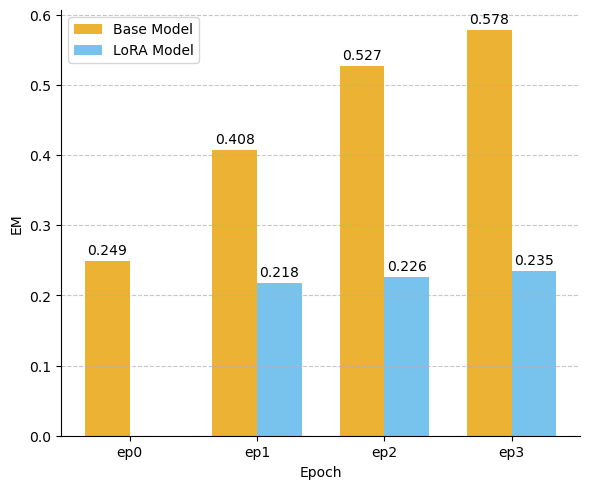

In [7]:
from matplotlib.lines import Line2D
from cycler import cycler

import matplotlib.pyplot as plt
import numpy as np

# Set up the plot
fig, ax = plt.subplots(figsize=(6, 5))

# EM data for both models
base_em = [base_means.loc[ep, 'em'] for ep in eps]
lo_em = [lo_means.loc[ep, 'em'] for ep in ['ep1', 'ep2', 'ep3']]  # lo_means doesn't have ep0

# Bar positions and width
x_pos = np.arange(len(eps))
bar_width = 0.35

# Plot base model EM
base_bars = ax.bar(x_pos - bar_width/2, base_em, bar_width, 
                   label='Base Model', color='#E69F00', alpha=0.8)

# Plot LoRA model EM (starting from ep1)
lo_bars = ax.bar(x_pos[1:] + bar_width/2, lo_em, bar_width, 
                 label='LoRA Model', color='#56B4E9', alpha=0.8)

# Customize the plot
ax.set_xlabel('Epoch')
ax.set_ylabel('EM')
# ax.set_title('Exact Match Performance: Base vs LoRA Model')
ax.set_xticks(x_pos)
ax.set_xticklabels(eps)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bars in [base_bars, lo_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)
        
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

fig.savefig('./lora_attack_mem_ep.pdf', format='pdf')

In [8]:
expath = '../attack_mem_plen'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_mem_plen.parquet'))

df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_plen/attack_mem_plen.parquet"))

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

In [9]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'7b_lo_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

lo_means = pd.DataFrame(mean_data, index=plens)
lo_means

,em,bleu,meteor,rougeL
p100,0.235,50.815781,0.568052,0.566612
p150,0.239,50.906638,0.569688,0.568148
p200,0.252,52.030764,0.585959,0.584063
p250,0.265,54.510058,0.619651,0.616311


In [10]:
# baseline_means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'7b_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

base_means = pd.DataFrame(mean_data, index=plens)
base_means

,em,bleu,meteor,rougeL
p100,0.578,74.995617,0.776693,0.778011
p150,0.646,77.325951,0.803730,0.798020
p200,0.712,80.200689,0.824692,0.818369
p250,0.800,84.977597,0.856810,0.856821


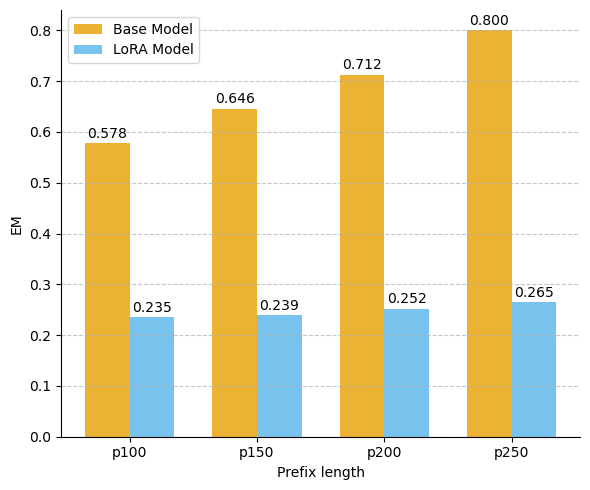

In [12]:
from matplotlib.lines import Line2D
from cycler import cycler

import matplotlib.pyplot as plt
import numpy as np

# Set up the plot
fig, ax = plt.subplots(figsize=(6, 5))
plens = ['p100', 'p150', 'p200', 'p250']

# EM data for both models
base_em = [base_means.loc[pl, 'em'] for pl in plens]
lo_em = [lo_means.loc[pl, 'em'] for pl in plens]  

# Bar positions and width
x_pos = np.arange(len(plens))
bar_width = 0.35

# Plot base model EM
base_bars = ax.bar(x_pos - bar_width/2, base_em, bar_width, 
                   label='Base Model', color='#E69F00', alpha=0.8)

# Plot LoRA model EM (starting from ep1)
lo_bars = ax.bar(x_pos + bar_width/2, lo_em, bar_width, 
                 label='LoRA Model', color='#56B4E9', alpha=0.8)

# Customize the plot
ax.set_xlabel('Prefix length')
ax.set_ylabel('EM')
# ax.set_title('Exact Match Performance: Base vs LoRA Model')
ax.set_xticks(x_pos)
ax.set_xticklabels(plens)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bars in [base_bars, lo_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)
        
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

fig.savefig('./lo_plen_mem_ep.pdf', format='pdf')